**1. Setup - Import Libraries**

In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score

import joblib

**2. Load dataset**

In [11]:
df = pd.read_csv("C:/Users/tiwar/OneDrive/Desktop/Customer Segmentation/Customer-Segmentation/dataset/mall_customer.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


**3. Dataset Information**

In [12]:
# dataset shape
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(200, 5)


In [13]:
# column names
print("\nColumns:")
print(df.columns)


Columns:
Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')


In [14]:
# data types
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB
None


In [15]:
# missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [16]:
# statistical summary
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000


**4. Data Visualization**

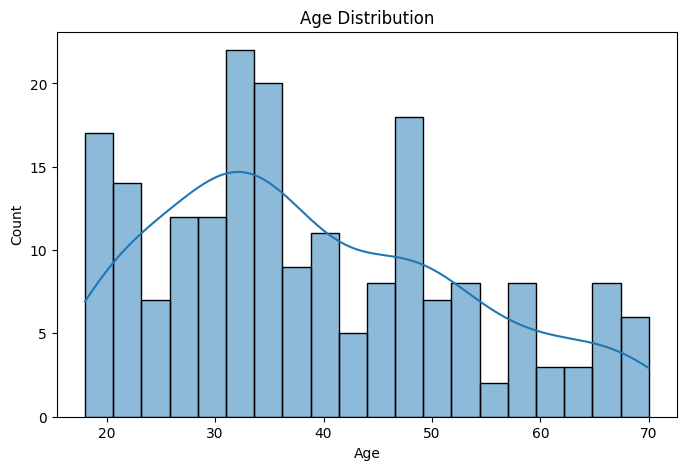

In [17]:
# age distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df["Age"],
    bins=20,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

**5. Income Vs Spending Score**

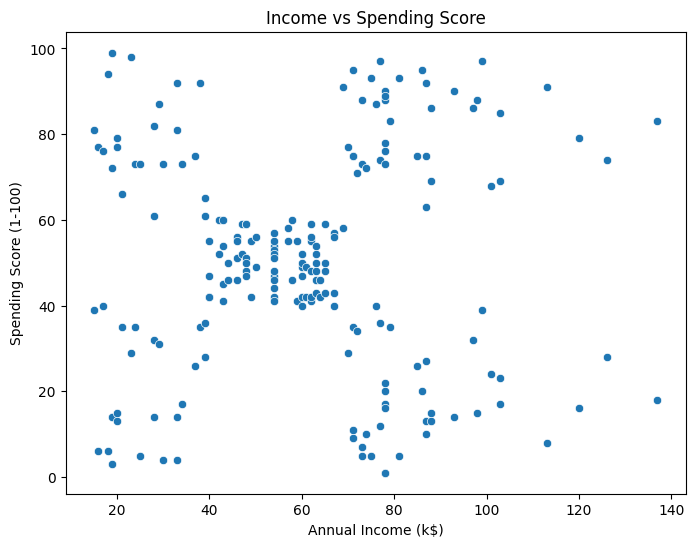

In [18]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    data=df
)

plt.title("Income vs Spending Score")

plt.show()

**6. Feature Selection**

In [19]:
features = [
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

X = df[features]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


**7. Feature Scaling**

In [20]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


**8. Elbow Method**

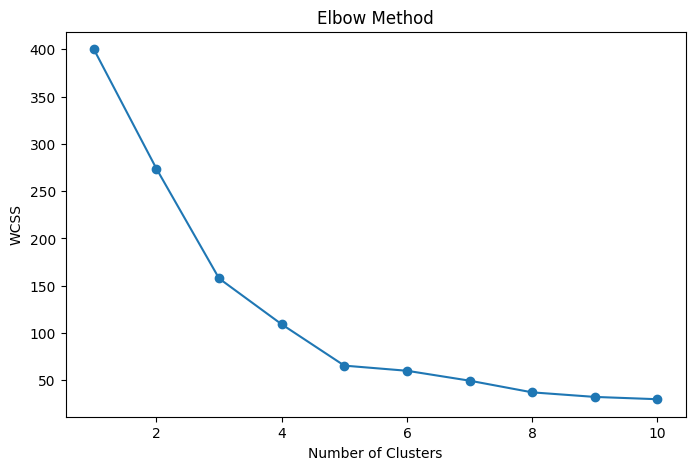

In [21]:
wcss = []

for i in range(1, 11):

    kmeans = KMeans(
        n_clusters=i,
        init="k-means++",
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

# plot elbow graph
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

**9. Train K-Means Model**

In [22]:
kmeans = KMeans(
    n_clusters=5,
    init="k-means++",
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

# add cluster column
df["Cluster"] = clusters

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [23]:
score = silhouette_score(
    X_scaled,
    clusters
)

print("Silhouette Score:", score)

Silhouette Score: 0.5546571631111091


**10. PCA Visualization**

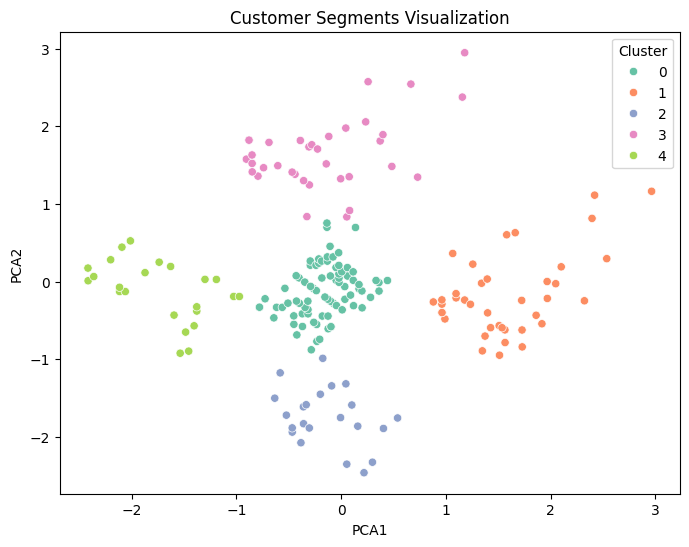

In [24]:
pca = PCA(n_components=2)

components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PCA1": components[:,0],
    "PCA2": components[:,1],
    "Cluster": clusters
})

plt.figure(figsize=(8,6))

sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    data=pca_df,
    palette="Set2"
)

plt.title("Customer Segments Visualization")

plt.show()

In [25]:
# cluster analysis
cluster_summary = df.groupby("Cluster")[
    [
        "Annual Income (k$)",
        "Spending Score (1-100)",
        "Age"
    ]
].mean()

cluster_summary

,Annual Income (k$),Spending Score (1-100),Age
Cluster,,,
0,55.296296,49.518519,42.716049
1,86.538462,82.128205,32.692308
2,25.727273,79.363636,25.272727
3,88.200000,17.114286,41.114286
4,26.304348,20.913043,45.217391


In [26]:
# save model
joblib.dump(
    kmeans,
    "../saved_models/kmeans.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [27]:
# save segmented dataset
df.to_csv(
    "../saved_models/segmented_customers.csv",
    index=False
)

print("Segmented Dataset Saved Successfully")

Segmented Dataset Saved Successfully


In [28]:
# final dataset preview
df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
5,6,Female,22,17,76,2
6,7,Female,35,18,6,4
7,8,Female,23,18,94,2
8,9,Male,64,19,3,4
9,10,Female,30,19,72,2
